In [1]:
import jax.numpy as jnp
import numpy as np 
import jax
import matplotlib.pyplot as plt 
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import diffrax
import equinox
import pyvista as pv
import scipy.signal

In [2]:
%matplotlib widget

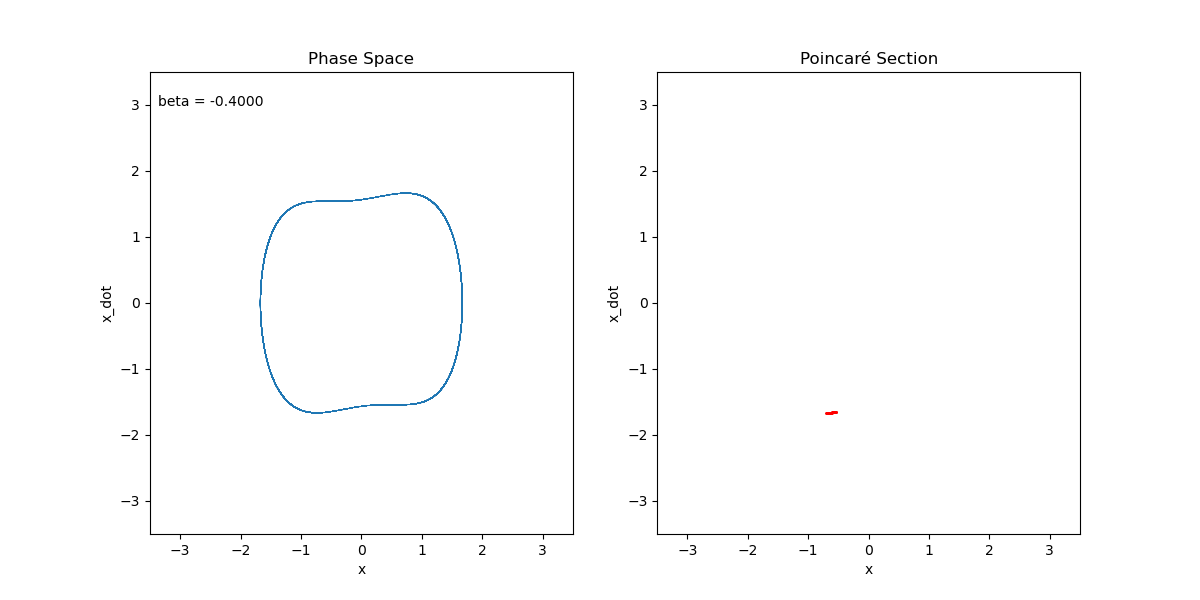

In [ ]:
# Constants
C = 0.0
k = 0.50
omega = 1.2
gamma = 1.0
alpha = 1.0
beta = -1.0

#pointcare time interval
T = 2 * jnp.pi / omega

theta_deg = 180  # angle in degrees
theta_time = (theta_deg / 360.0) * T 

numFrames = 1000

#variable to sweep across, should match name from constants
varToTest = "beta"
minVal = -2.2
maxVal = -.4
values = jnp.linspace(minVal,maxVal, numFrames)



def dx_dt(t, x, params):
    #Basic Duffing ODE, added a term 'C' to show constant slope.
    C = params["C"]
    k = params["k"]
    omega = params["omega"]
    gamma = params["gamma"]
    alpha = params["alpha"]
    beta = params["beta"]

    return jnp.array([
        x[1],
        -beta*x[0]
        - k*x[1]
        - alpha*x[0]**3
        + gamma*jnp.cos(omega*t)
        + C
    ])

#Get our ODE solver setup
term = diffrax.ODETerm(dx_dt)
solver = diffrax.Tsit5()
y0 = jnp.array([0.0, 1.0])
ts = jnp.linspace(4000, 5000, 10000)

def solve_single(value):
    #Solde the ODE for one snapshot of constants
    params = {"C":C,"k":k,"omega":omega,"gamma":gamma,"alpha":alpha,"beta":beta}
    params[varToTest] = value  

    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0,
        t1=5000,
        dt0=0.05,
        y0=y0,
        args=params,
        saveat=diffrax.SaveAt(ts=ts),
        max_steps=1_000_000,
    )
    return sol.ys

#call all the jax stuff up to now
batched_solve = jax.vmap(solve_single)
solutions = batched_solve(values)[:,1000:,] #throw away first 1000 points to focus on steady state operation

#matplotlib junk
fig, (ax_phase, ax_poincare) = plt.subplots(1, 2, figsize=(12,6))
phase_line, = ax_phase.plot([], [], lw=0.5)
poincare_scatter = ax_poincare.scatter(
    [], [],
    s=2,           
    c="red",       
    marker=".",    
)

ax_phase.set_title("Phase Space")
ax_phase.set_xlabel("x")
ax_phase.set_ylabel("x_dot")
ax_poincare.set_title("Poincaré Section")
ax_poincare.set_xlabel("x")
ax_poincare.set_ylabel("x_dot")
ax_phase.set_xlim(-3.5,3.5)
ax_phase.set_ylim(-3.5,3.5)
ax_poincare.set_xlim(-3.5,3.5)
ax_poincare.set_ylim(-3.5,3.5)
param_text = ax_phase.text( #Set up persistant text on top of plot we can iterate with the constan's value
    0.02, 0.95, "",
    transform=ax_phase.transAxes,
    verticalalignment="top"
)

ts_array = ts[1000:]

poincare_times = jnp.arange(ts_array[0], ts_array[-1], T) + theta_time

idx = jnp.searchsorted(ts_array, poincare_times)
idx = jnp.clip(idx, 1, len(ts_array) - 1)

left = ts_array[idx - 1]
right = ts_array[idx]

choose_left = jnp.abs(poincare_times - left) < jnp.abs(poincare_times - right)

poincare_indices = jnp.where(choose_left, idx - 1, idx)


def update(frame):
    #Function required for animation, just goes through and crunches all the numbers for one frame of the animation
    current_value = values[frame]
    trajectory = solutions[frame]

    phase_line.set_data(
        trajectory[:,0],
        trajectory[:,1]
    )

    poincare = trajectory[poincare_indices][100:]

    poincare_scatter.set_offsets(
        jnp.column_stack((poincare[:,0], poincare[:,1]))
    )

    param_text.set_text(
        f"{varToTest} = {float(current_value):.4f}"
    )

    return phase_line, poincare_scatter, param_text

ani = animation.FuncAnimation(
    #Create a matplotlib animation
    fig, update, frames=numFrames, interval=50
)

fileName = f"duffingk0_5{str(varToTest).replace('.', '_')}min{str(minVal).replace('.', '_')}max{str(maxVal).replace('.', '_')}Theta{str(theta_deg).replace('.', '_')}.mp4"

ani.save(fileName, writer="ffmpeg", fps=10)

poincare_data = []

for i, value in enumerate(values):
    trajectory = solutions[i]
    poincare = trajectory[poincare_indices][100:]
    poincare_data.append(
        np.column_stack(
            (poincare[:, 0], poincare[:, 1], np.full(poincare.shape[0], value))
        )
    )

points = np.vstack(poincare_data)

cloud = pv.PolyData(points)

plotter = pv.Plotter()
plotter.add_points(
    cloud,
    color="black",
    point_size=3,
    render_points_as_spheres=False
)

plotter.add_axes()
plotter.show_grid( 
    xtitle="x",
    ytitle="xdot",
    ztitle=f"{varToTest} (swept parameter)")

plotter.export_html(f"HTML{fileName}.html")

In [ ]:
#matplotlib junk
fig, (ax_phase, ax_poincare) = plt.subplots(1, 2, figsize=(12,6))
phase_line, = ax_phase.plot([], [], lw=0.5)
poincare_scatter = ax_poincare.scatter(
    [], [],
    s=2,           
    c="red",       
    marker=".",    
)

ax_phase.set_title("Phase Space")
ax_phase.set_xlabel("x")
ax_phase.set_ylabel("x_dot")
ax_poincare.set_title("Poincaré Section")
ax_poincare.set_xlabel("x")
ax_poincare.set_ylabel("x_dot")
ax_phase.set_xlim(-2,2)
ax_phase.set_ylim(-2,2)
ax_poincare.set_xlim(-2,2)
ax_poincare.set_ylim(-2,2)
param_text = ax_phase.text( #Set up persistant text on top of plot we can iterate with the constan's value
    0.02, 0.95, "",
    transform=ax_phase.transAxes,
    verticalalignment="top"
)

ts_array = ts[1000:]

poincare_times = jnp.arange(ts_array[0], ts_array[-1], T) + theta_time

idx = jnp.searchsorted(ts_array, poincare_times)
idx = jnp.clip(idx, 1, len(ts_array) - 1)

left = ts_array[idx - 1]
right = ts_array[idx]

choose_left = jnp.abs(poincare_times - left) < jnp.abs(poincare_times - right)

poincare_indices = jnp.where(choose_left, idx - 1, idx)


def update(frame):
    #Function required for animation, just goes through and crunches all the numbers for one frame of the animation
    current_value = values[frame]
    trajectory = solutions[frame]

    phase_line.set_data(
        trajectory[:,0],
        trajectory[:,1]
    )

    poincare = trajectory[poincare_indices][100:]

    poincare_scatter.set_offsets(
        jnp.column_stack((poincare[:,0], poincare[:,1]))
    )

    param_text.set_text(
        f"{varToTest} = {float(current_value):.4f}"
    )

    return phase_line, poincare_scatter, param_text

ani = animation.FuncAnimation(
    #Create a matplotlib animation
    fig, update, frames=numFrames, interval=50
)

fileName = f"duffingk0_5{str(varToTest).replace('.', '_')}min{str(minVal).replace('.', '_')}max{str(maxVal).replace('.', '_')}Theta{str(theta_deg).replace('.', '_')}.mp4"

ani.save(fileName, writer="ffmpeg", fps=10)

poincare_data = []

for i, value in enumerate(values):
    trajectory = solutions[i]
    poincare = trajectory[poincare_indices][100:]
    poincare_data.append(
        np.column_stack(
            (poincare[:, 0], poincare[:, 1], np.full(poincare.shape[0], value))
        )
    )

points = np.vstack(poincare_data)

cloud = pv.PolyData(points)

plotter = pv.Plotter()
plotter.add_points(
    cloud,
    color="black",
    point_size=3,
    render_points_as_spheres=False
)

plotter.add_axes()
plotter.show_grid( 
    xtitle="x",
    ytitle="xdot",
    ztitle=f"{varToTest} (swept parameter)")

plotter.export_html(f"HTML{fileName}.html")

476 Failed


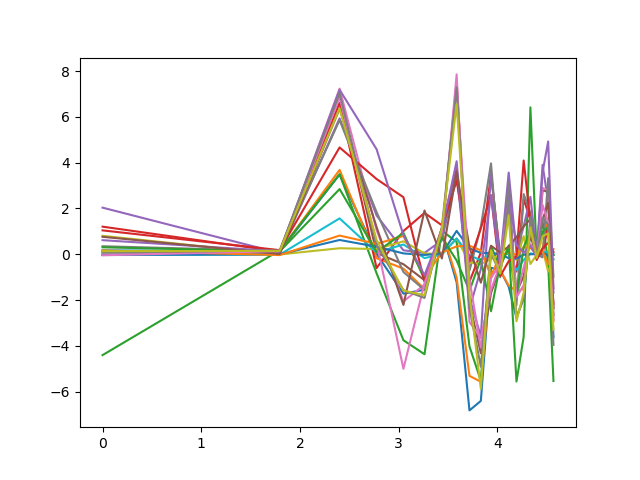

In [ ]:
i = 250
zerosx1 = jnp.diff(jnp.where(jnp.diff(jnp.sign(solutions[i,:,0])))[0])
zerosy1 = jnp.diff(jnp.where(jnp.diff(jnp.sign(solutions[i,:,1])))[0])
fft1 = scipy.signal.lombscargle(range(len(zerosx1)),zerosx1,np.linspace(1,1000,200))
ffty1 = scipy.signal.lombscargle(range(len(zerosy1)),zerosy1,np.linspace(1,1000,200))

twos = []

fig = plt.figure()
for i in range(1,500,25):
    #print(i)
    zerosx = jnp.diff(jnp.where(jnp.diff(jnp.sign(solutions[i,:,0])))[0])
    zerosy = jnp.diff(jnp.where(jnp.diff(jnp.sign(solutions[i,:,1])))[0])
    try:
        fft = scipy.signal.lombscargle(range(len(zerosx)),zerosx,np.linspace(1,1000,200))
        ffty = scipy.signal.lombscargle(range(len(zerosy)),zerosy,np.linspace(1,1000,200))
        plt.plot(np.log(np.linspace(1,1000,200))[:20],(np.log(ffty)-np.log(ffty1))[:20])
        twos.append((np.log(ffty)-np.log(ffty1))[2])
    except:
        print(f'{i} Failed')
    #plt.plot(np.log(np.linspace(1,1000,200)),np.log(fft))
   

[np.float64(3.4844875281244807),
 np.float64(3.6843280829045235),
 np.float64(3.498788846377534),
 np.float64(6.611207489920021),
 np.float64(5.9375174494165),
 np.float64(6.9562815768052335),
 np.float64(7.233993955604298),
 np.float64(5.86040861659214),
 np.float64(0.26277788766225596),
 np.float64(1.5676311149328999),
 np.float64(0.6240348622384644),
 np.float64(0.8163430548945583),
 np.float64(2.846728784294113),
 np.float64(4.66603027446933),
 np.float64(7.184987491320603),
 np.float64(6.36351552787135),
 np.float64(6.851529747424328),
 np.float64(7.043187662076184),
 np.float64(6.3756328200719175)]

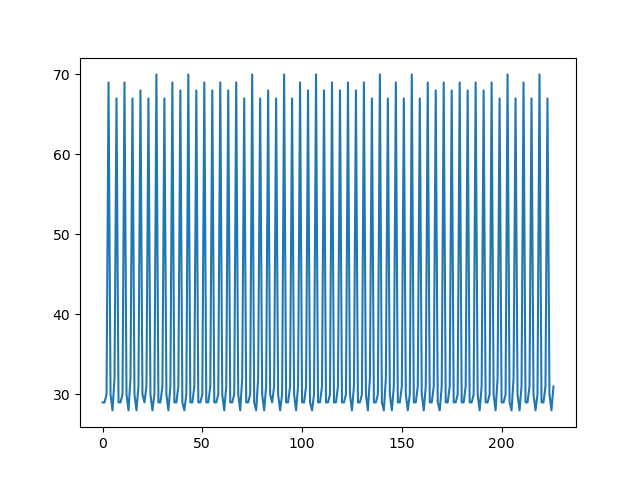

In [ ]:
fig = plt.figure()
plt.plot()

In [ ]:
poincare_data = []

for i, value in enumerate(values):
    trajectory = solutions[i]
    poincare = trajectory[poincare_indices][100:]
    poincare_data.append(
        np.column_stack(
            (poincare[:, 0], poincare[:, 1], np.full(poincare.shape[0], value))
        )
    )

points = np.vstack(poincare_data)

cloud = pv.PolyData(points)

plotter = pv.Plotter()
plotter.add_points(
    cloud,
    color="black",
    point_size=3,
    render_points_as_spheres=False
)

plotter.add_axes()
plotter.show_grid()

plotter.export_html(f"HTML{fileName}.html")

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/thomas/miniconda3/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x790d346fd340> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/thomas/miniconda3/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x790d346fd340> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/thomas/miniconda3/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._call

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/thomas/miniconda3/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
    ~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/thomas/miniconda3/lib/python3.13/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
    ~~~~~~~~~^^
  File "/home/thomas/miniconda3/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
    ~~~~~~~~~~~~~~~~~~^^
  File "/home/thomas/miniconda3/lib/python3.13/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/thomas/miniconda3/lib/python3.13/asyncio/base_events.py", line 683, in run_forever
    self._run_once()
    ~~~~~~~~~~~~~~^^
  File "/home/thomas/miniconda3/lib/python3.13/asyncio/base_e

: 

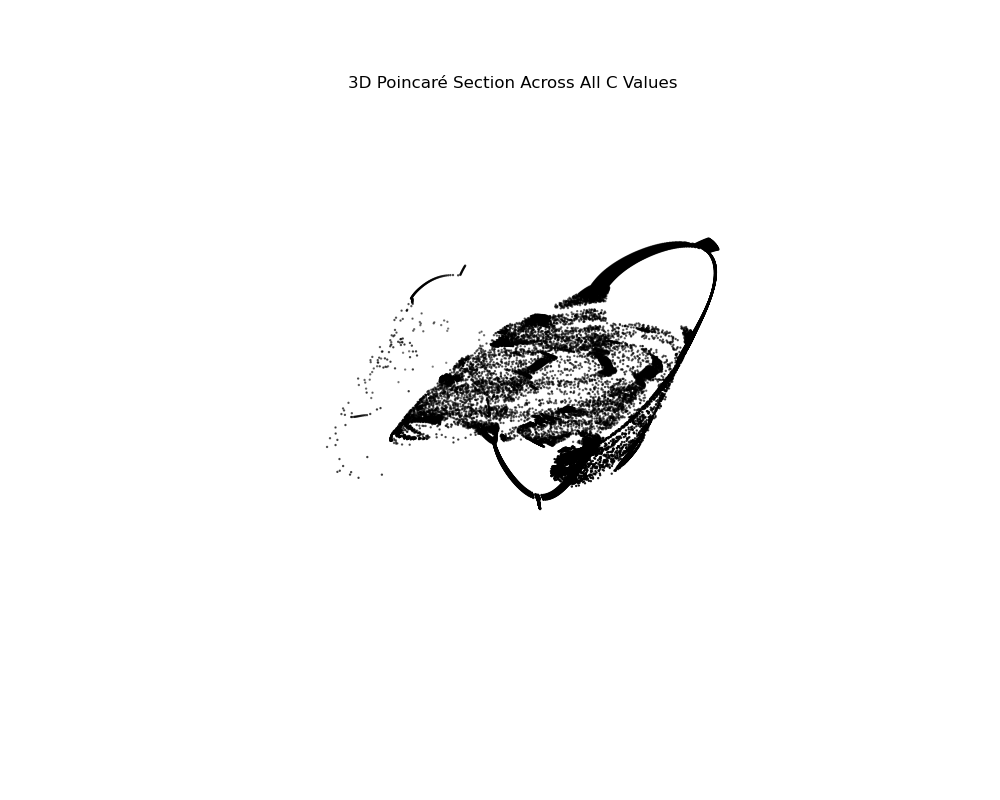

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

poincare_data = []

for i, value in enumerate(values):
    trajectory = solutions[i]
    poincare = trajectory[poincare_indices][100:]
    
    # Add the C value as the third dimension
    poincare_data.append(np.column_stack((poincare[:, 0], poincare[:, 1], np.full(poincare.shape[0], value))))

poincare_data = np.vstack(poincare_data)

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(poincare_data[:, 0], poincare_data[:, 1], poincare_data[:, 2], s=2, c='black', marker='.')

ax.set_xlabel('x')
ax.set_ylabel('x_dot')
ax.set_zlabel(f'{varToTest} (C)')


ax.set_title("3D Poincaré Section Across All C Values")

plt.show()

In [6]:
import numpy as np
import pyvista as pv

poincare_data = []

for i, value in enumerate(values):
    trajectory = solutions[i]
    poincare = trajectory[poincare_indices][100:]
    poincare_data.append(
        np.column_stack(
            (poincare[:, 0], poincare[:, 1], np.full(poincare.shape[0], value))
        )
    )

points = np.vstack(poincare_data)

cloud = pv.PolyData(points)

plotter = pv.Plotter()
plotter.add_points(
    cloud,
    color="black",
    point_size=3,
    render_points_as_spheres=False
)

plotter.add_axes()
plotter.show_grid()

plotter.export_html("pointcloud.html")

36000


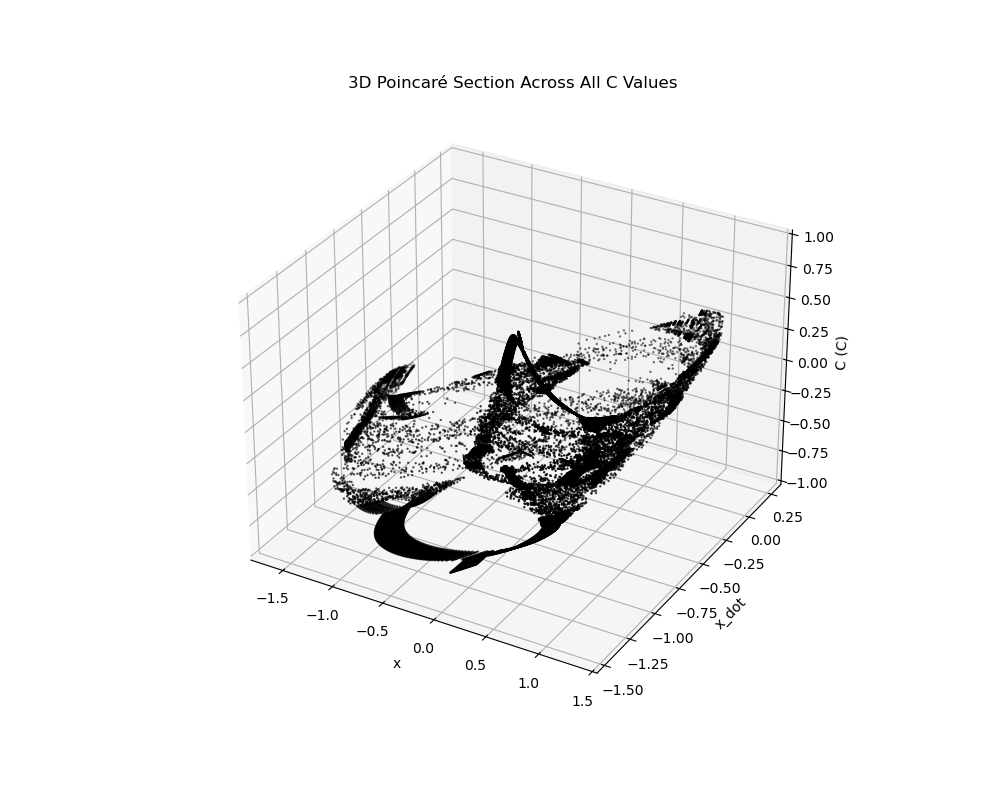

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

poincare_data = []

for i, value in enumerate(values):
    trajectory = solutions[i]
    poincare = trajectory[poincare_indices][100:]
    poincare_data.append(
        np.column_stack(
            (poincare[:, 0], poincare[:, 1], np.full(poincare.shape[0], value))
        )
    )

poincare_data = np.vstack(poincare_data)

print(len(poincare_data))


# Create figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
sc = ax.scatter(
    poincare_data[:, 0],
    poincare_data[:, 1],
    poincare_data[:, 2],
    s=2,
    c='black',
    marker='.'
)

ax.set_xlabel('x')
ax.set_ylabel('x_dot')
ax.set_zlabel(f'{varToTest} (C)')
ax.set_title("3D Poincaré Section Across All C Values")

# Set fixed elevation
elevation = 20

def update(frame):
    ax.view_init(elev=frame, azim=90)
    return ax,

# Animate 360 degrees
ani = FuncAnimation(
    fig,
    update,
    frames=np.linspace(0, 360, 180), 
    interval=50
)

plt.show()
ani.save("poincare_rotationZNTheta180.mp4", writer='ffmpeg', fps=30)

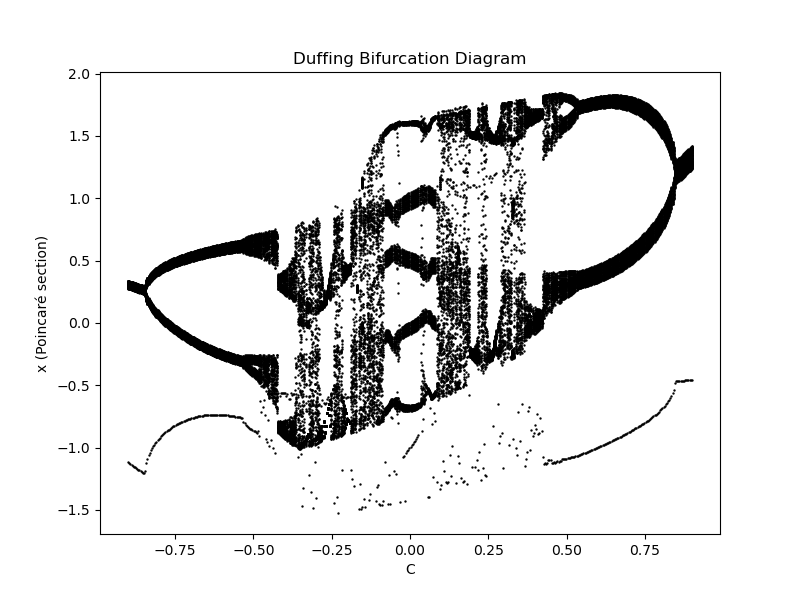

In [4]:
all_x = []
all_params = []

for i, value in enumerate(values):
    trajectory = solutions[i]

    poincare = trajectory[poincare_indices][100:]  # skip transients

    x_vals = poincare[:,0]

    all_x.append(x_vals)
    all_params.append(jnp.full_like(x_vals, value))

all_x = jnp.concatenate(all_x)
all_params = jnp.concatenate(all_params)

plt.figure(figsize=(8,6))
plt.scatter(all_params, all_x, s=0.5, color="black")

plt.xlabel("C")
plt.ylabel("x (Poincaré section)")
plt.title("Duffing Bifurcation Diagram")

plt.show()

In [10]:
theta_values = jnp.linspace(0, T, 6)

ts_array = ts[1000:]

def get_indices(theta):
    poincare_times = jnp.arange(ts_array[0], ts_array[-1], T) + theta
    return jnp.searchsorted(ts_array, poincare_times)

theta_indices = [get_indices(theta) for theta in theta_values]

def get_poincare(theta):
    poincare_times = jnp.arange(ts_array[0], ts_array[-1], T) + theta
    indices = jnp.searchsorted(ts_array, poincare_times)
    return indices

In [15]:
import numpy as np
import pyvista as pv

xs = []
params = []
thetas = []

for theta, indices in zip(theta_values, theta_indices):
    for i, value in enumerate(values):

        trajectory = solutions[i]
        poincare = trajectory[indices][100:]

        xvals = poincare[:, 0]

        xs.append(xvals)
        params.append(jnp.full_like(xvals, value))
        thetas.append(jnp.full_like(xvals, theta))

# Convert to numpy arrays
xs = np.concatenate(xs)
params = np.concatenate(params)
thetas = np.concatenate(thetas)

# PyVista expects points as (N,3)
points = np.column_stack([params, thetas, xs])

# Create point cloud
cloud = pv.PolyData(points)

# Attach scalar for coloring
cloud["xvals"] = xs

plotter = pv.Plotter()
plotter.add_points(
    cloud,
    color="blue",
    point_size=2,
    render_points_as_spheres=True
)

plotter.show_grid(
    ytitle='Theta',
    xtitle='C',
    ztitle='Poincare x'
)
plotter.export_html('Phase Space Poincare.html')

plotter.show()

Widget(value='<iframe src="http://localhost:37687/index.html?ui=P_0x746dfa06f110_8&reconnect=auto" class="pyvi…

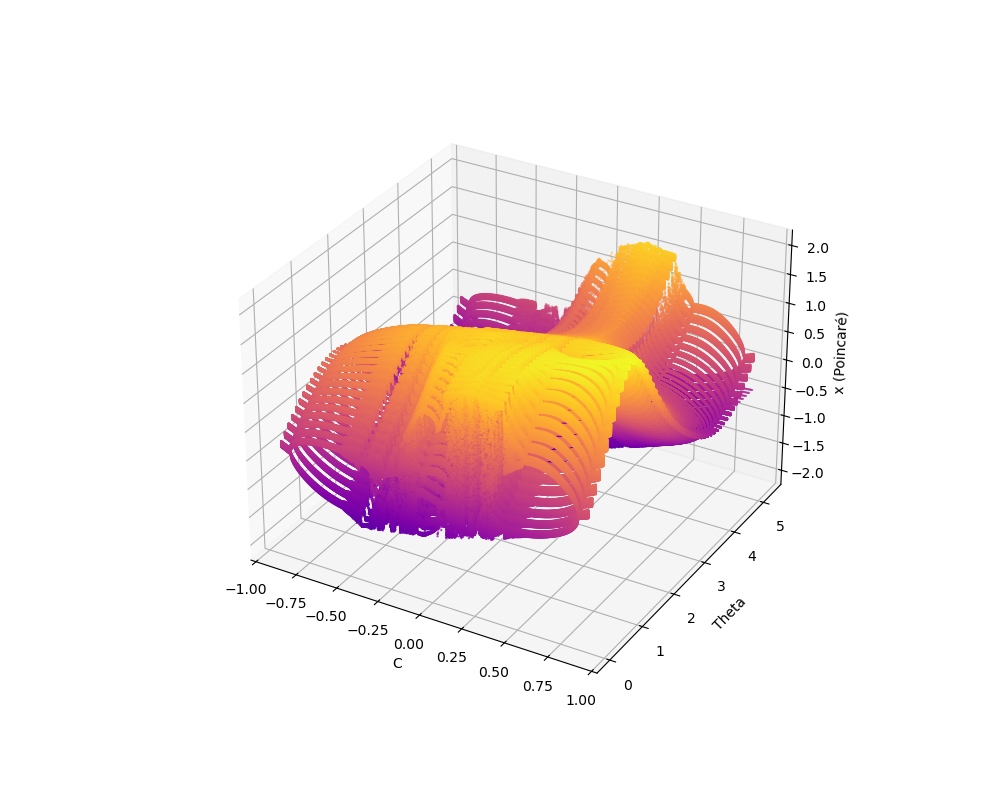

In [6]:
xs = []
params = []
thetas = []

for theta, indices in zip(theta_values, theta_indices):

    for i, value in enumerate(values):

        trajectory = solutions[i]
        poincare = trajectory[indices][100:]

        xvals = poincare[:,0]

        xs.append(xvals)
        params.append(jnp.full_like(xvals, value))
        thetas.append(jnp.full_like(xvals, theta))

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(params, thetas, xs, s=0.3, c=xs, cmap="plasma")

ax.set_xlabel("C")
ax.set_ylabel("Theta")
ax.set_zlabel("x (Poincaré)")

plt.show()